# 导入所需要的库

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#matplotlib inline

# 导入数据

In [12]:
data=pd.read_csv(r'数据集\data_processed\data_clean.csv')
data.head()

,order_id,customer_id,customer_unique_id,customer_region,seller_id,seller_region,product_id,product_category_high,volume,weight,process_time,is_delay,distance,freight_total,price_total,purchase_hour,purchase_dayofweek,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,Southeast,3504c0cb71d7fa48d967e0e4c94d59d9,Southeast,87285b34884572647811a353c7ac498a,HomeLiving,988000.0,0.50,0.178333,0,18.576110,8.72,29.99,10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,Northeast,289cdb325fb7e7f891c38608bf9e0962,Southeast,595fac2a385ac33a80bd5114aec74eb8,BeautyHealth,1877200.0,0.40,30.713889,0,851.495069,22.76,118.70,20,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,CentralWest,4869f7a5dfa277a7dca6462dcf3b52b2,Southeast,aa4383b373c6aca5d8797843e5594415,Other,4021920.0,0.42,0.276111,0,514.410666,19.22,159.90,8,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,Northeast,66922902710d126a0e7d26b0e3805106,Southeast,d0b61bfb1de832b15ba9d266ca96e5b0,PetSupplies,2700000.0,0.45,0.298056,0,1822.226336,27.20,45.00,19,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,Southeast,2c9e548be18521d1c43cde1c582c6de8,Southeast,65266b2da20d04dbe00c5c2d3bb7859e,BooksStationery,2868750.0,0.25,1.030556,0,29.676625,8.72,19.90,21,1,2


# 可视化

## 1.商品体积与物流延误的关系

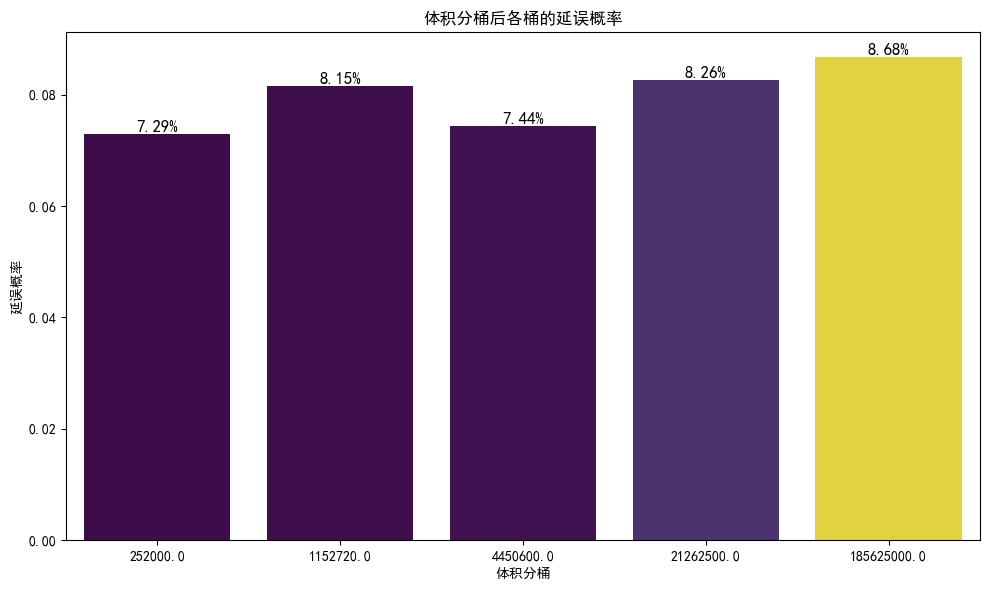

In [13]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
data['volume_bin']=pd.qcut(data['volume'],q=5)
data['volume_bin'] = data.groupby('volume_bin', observed=True)['volume'].transform('median')
volume_isdelay_rate = data.groupby('volume_bin')['is_delay'].mean().reset_index()
plt.figure(figsize=(10, 6))
ax1=sns.barplot(x='volume_bin', y='is_delay', data=volume_isdelay_rate, palette='viridis',hue='volume_bin',legend=False)
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f'{height:.2%}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', 
        va='bottom',
        fontsize=12
    )
plt.title('体积分桶后各桶的延误概率')
plt.xlabel('体积分桶')
plt.ylabel('延误概率')
plt.tight_layout()
plt.show()

体积大小与延误率存在正相关的关系

## 2.商品重量与延误率的关系

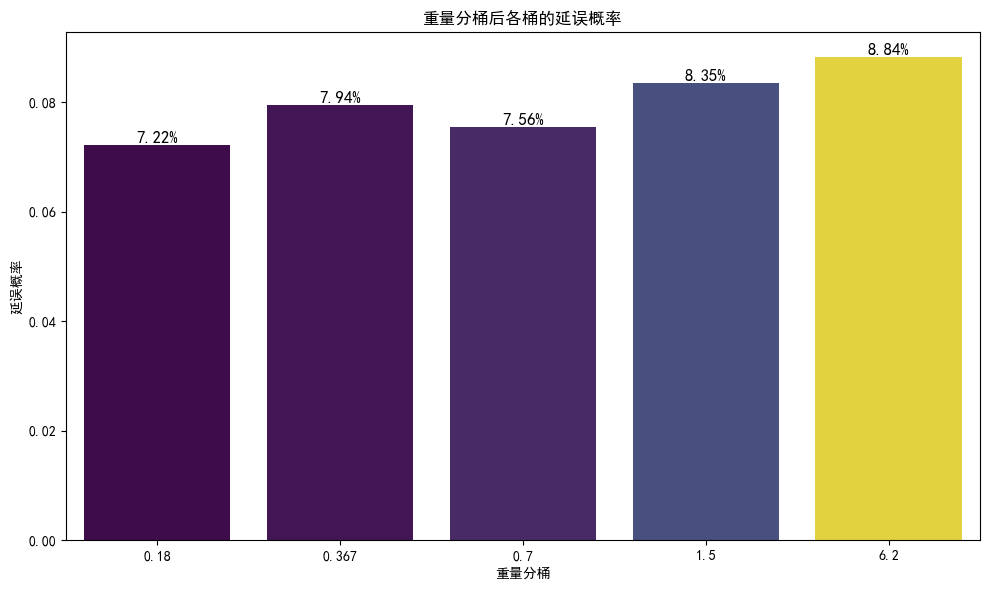

In [16]:
data['weight_bin']=pd.qcut(data['weight'],q=5)
data['weight_bin'] = data.groupby('weight_bin', observed=True)['weight'].transform('median')
weight_isdelay_rate = data.groupby('weight_bin')['is_delay'].mean().reset_index()
plt.figure(figsize=(10, 6))
ax2=sns.barplot(x='weight_bin', y='is_delay', data=weight_isdelay_rate, palette='viridis',hue='weight_bin',legend=False)
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(
        f'{height:.2%}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom', 
        fontsize=12)
plt.title('重量分桶后各桶的延误概率')
plt.xlabel('重量分桶')
plt.ylabel('延误概率')
plt.tight_layout()
plt.show()

商品重量与物流延误概率存在正相关

## 3.距离与是否延误之间的关系

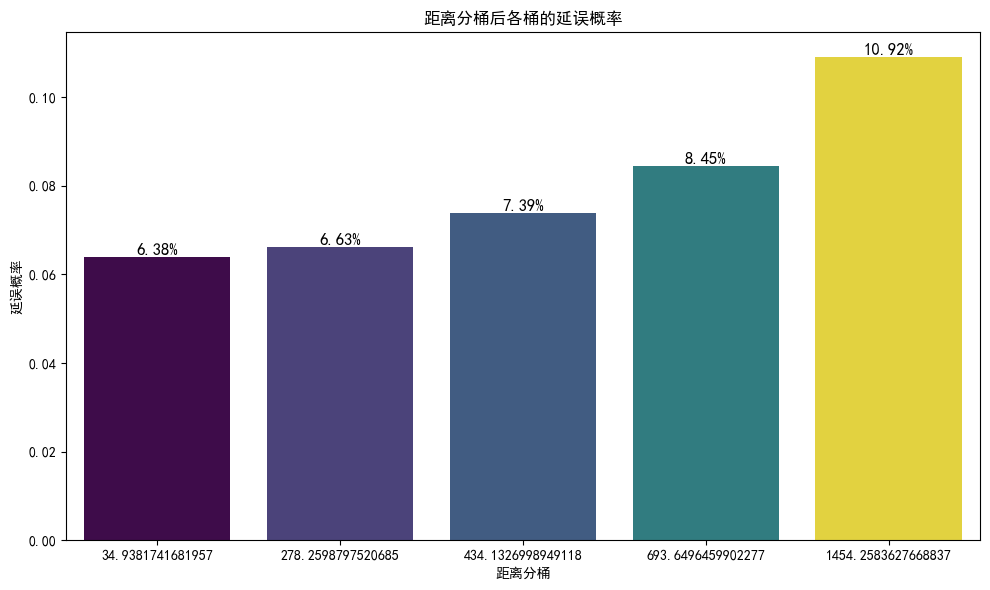

In [17]:
data['distance_bin']=pd.qcut(data['distance'],q=5)
data['distance_bin'] = data.groupby('distance_bin', observed=True)['distance'].transform('median')
distance_isdelay_rate = data.groupby('distance_bin')['is_delay'].mean().reset_index()
plt.figure(figsize=(10, 6))
ax3=sns.barplot(x='distance_bin', y='is_delay', data=distance_isdelay_rate, palette='viridis',hue='distance_bin',legend=False)
for p in ax3.patches:
    height = p.get_height()
    ax3.annotate(
        f'{height:.2%}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom', 
        fontsize=12)
plt.title('距离分桶后各桶的延误概率')
plt.xlabel('距离分桶')
plt.ylabel('延误概率')
plt.tight_layout()
plt.show()

距离与延误率之间存在正相关

## 4.下单时间与延误率之间的关系

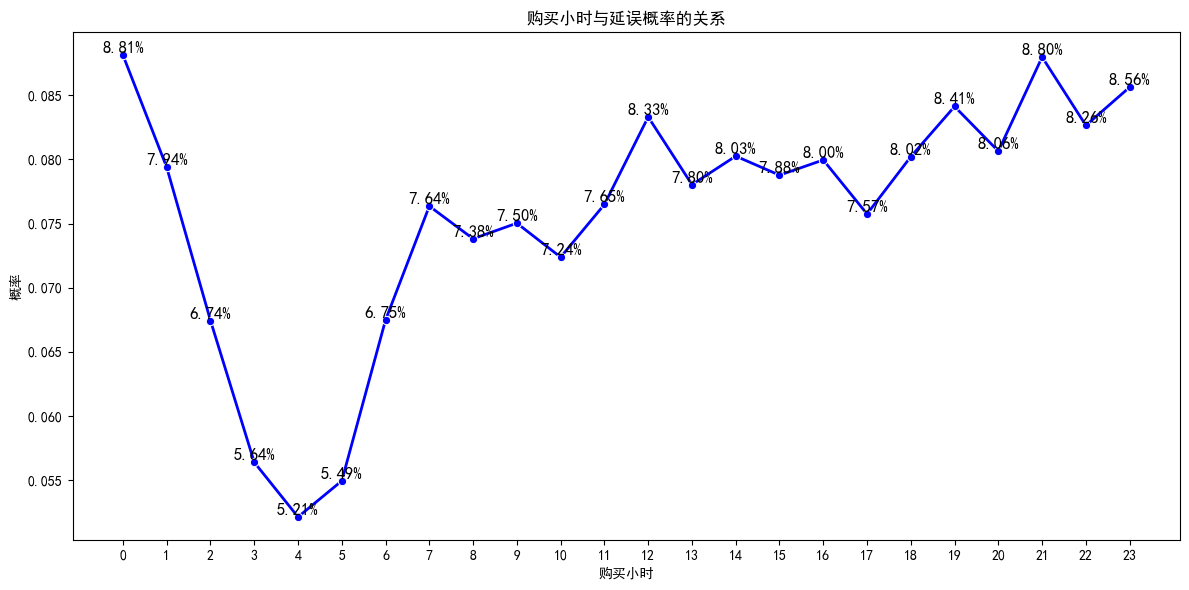

In [40]:
purchase_hour_isdelay_rate = data.groupby('purchase_hour')['is_delay'].mean().reset_index()
plt.figure(figsize=(12, 6))
ax4=sns.lineplot(x='purchase_hour', y='is_delay', data=purchase_hour_isdelay_rate,marker='o', color='blue',linewidth=2)
for line in ax4.lines:
    x=line.get_xdata()
    y=line.get_ydata()
    for xi,yi in zip(x,y):
        ax4.annotate(
            f'{yi:.2%}',
            xy=(xi,yi),
            ha='center',
            va='bottom',
            fontsize=12)
full_x_ticks = purchase_hour_isdelay_rate['purchase_hour'].tolist()
ax4.set_xticks(full_x_ticks)
plt.title('购买小时与延误概率的关系')
plt.xlabel('购买小时')
plt.ylabel('概率')
plt.tight_layout()
plt.show()

在巴西当地的3-5点下单的延误率显著低于其他时间段，凌晨3-5点下单客户较少，处理效率较高。

## 5.下单月份与延误率之间的关系

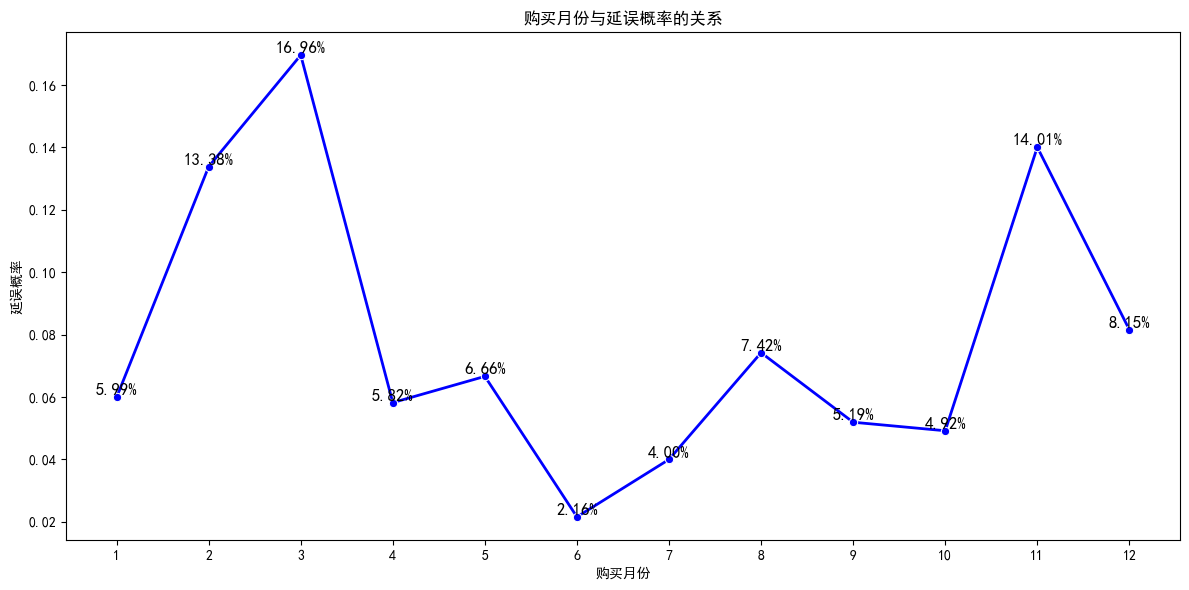

In [41]:
purchase_month_isdelay_rate = data.groupby('purchase_month')['is_delay'].mean().reset_index()
plt.figure(figsize=(12, 6))
ax5=sns.lineplot(x='purchase_month', y='is_delay', data=purchase_month_isdelay_rate,marker='o', color='blue',linewidth=2)
for line in ax5.lines:
    x=line.get_xdata()
    y=line.get_ydata()
    for xi,yi in zip(x,y):
        ax5.annotate(
            f'{yi:.2%}',
            xy=(xi,yi),
            ha='center',
            va='bottom',
            fontsize=12)
full_x_ticks = purchase_month_isdelay_rate['purchase_month'].tolist()
ax5.set_xticks(full_x_ticks)
plt.title('购买月份与延误概率的关系')
plt.xlabel('购买月份')
plt.ylabel('延误概率')
plt.tight_layout()
plt.show()

在二三月份和十一月份延误率显著高于其他月份，在二月中下旬到三月初为巴西狂欢节，物流效率下降，订单增加，十一月有巴西的黑色星期五，订单暴增，物流压力大，十二月有圣诞节，订单增加

## 6.下单日期与延误率之间的关系

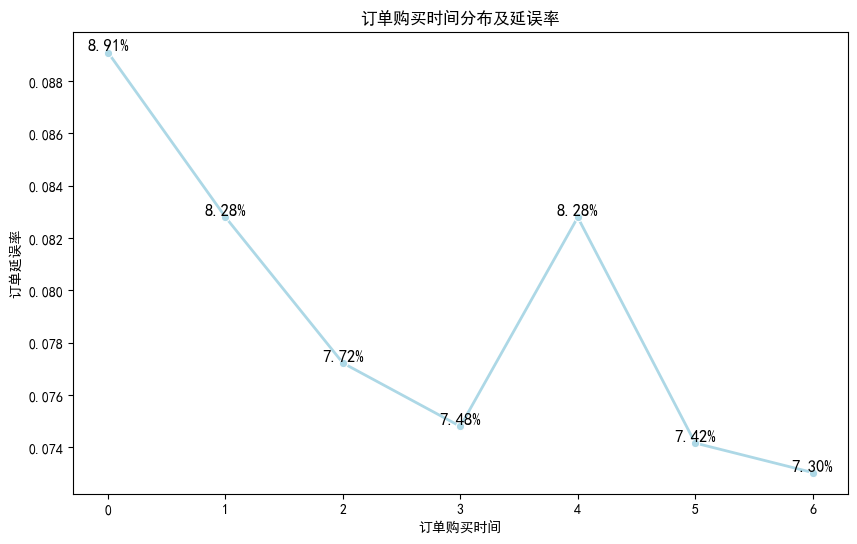

In [42]:
purchase_day_of_week_isdelay_rate = data.groupby('purchase_dayofweek')['is_delay'].mean().reset_index()
plt.figure(figsize=(10, 6))
ax6=sns.lineplot(x='purchase_dayofweek', y='is_delay', data=purchase_day_of_week_isdelay_rate,marker='o', color='lightblue',linewidth=2)
for line in ax6.lines:
    x=line.get_xdata()
    y=line.get_ydata()
    for xi,yi in zip(x,y):
        ax6.annotate(
            f'{yi:.2%}',
            xy=(xi,yi),
            ha='center',
            va='bottom',
            fontsize=12)
full_x_ticks = purchase_day_of_week_isdelay_rate['purchase_dayofweek'].tolist()
ax6.set_xticks(full_x_ticks)
ax6.set_title('订单购买时间分布及延误率')
ax6.set_xlabel('订单购买时间')
ax6.set_ylabel('订单延误率')
plt.show()

周末用户休闲时间充足，用户一般选择陪伴家人游玩，周一上班后会产生大量订单。

## 7.商家地区与延误率之间的关系

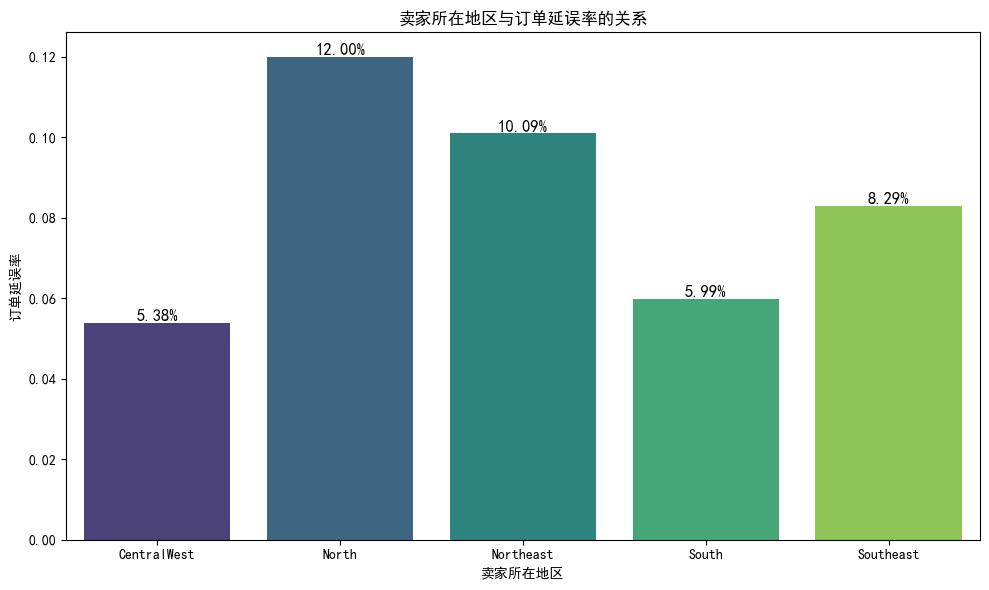

In [43]:
seller_region_isdelay_rate = data.groupby('seller_region')['is_delay'].mean().reset_index()
plt.figure(figsize=(10,6))
ax7=sns.barplot(x='seller_region', y='is_delay', data=seller_region_isdelay_rate, palette='viridis',hue='seller_region',legend=False)
for p in ax7.patches:
    height = p.get_height()
    ax7.annotate(
        f"{height:.2%}", 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha = 'center', 
        va = 'bottom',
        fontsize=12)
plt.title('卖家所在地区与订单延误率的关系')
plt.xlabel('卖家所在地区')
plt.ylabel('订单延误率')
plt.tight_layout()
plt.show()

订单商家在北部地区的商家延误率最高，其次是东北部，中西部的商家订单延误率最低，北部地区为亚马逊雨林地区，交通不发达，中西部为内陆，交通发达，东南方地区经济发达，同时订单数量较多

## 8.顾客地区与延误率之间的关系

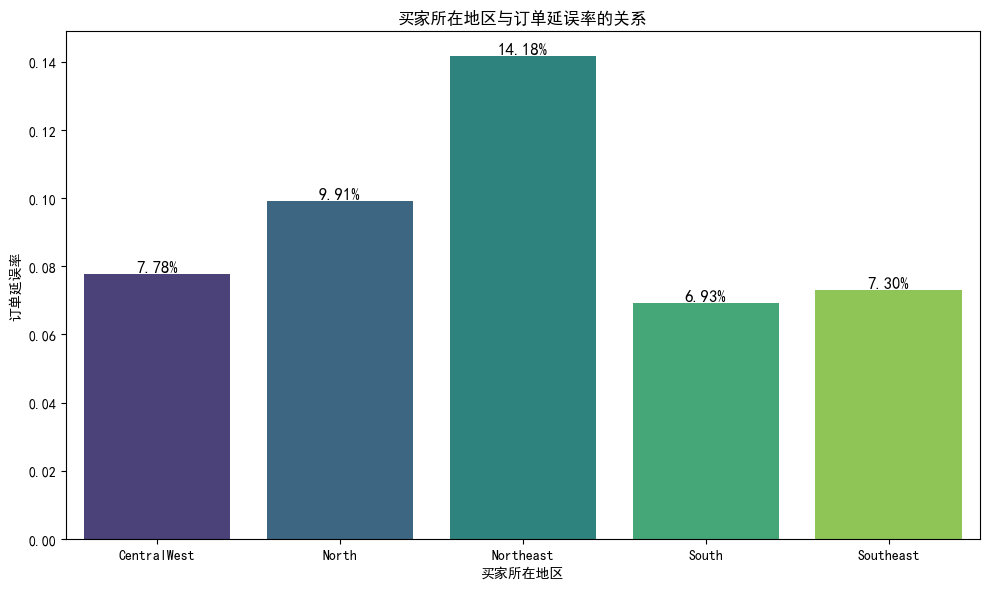

In [44]:
customer_region_isdelay_rate = data.groupby('customer_region')['is_delay'].mean().reset_index()
plt.figure(figsize=(10,6))
ax8=sns.barplot(x='customer_region', y='is_delay', data=customer_region_isdelay_rate, palette='viridis',hue='customer_region',legend=False)
for p in ax8.patches:
    height = p.get_height()
    ax8.annotate(
        f"{height:.2%}", 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha = 'center', 
        va = 'bottom',
        fontsize=12)
ax8.set_title('买家所在地区与订单延误率的关系')
ax8.set_xlabel('买家所在地区')
ax8.set_ylabel('订单延误率')
plt.tight_layout()
plt.show()

北部与东北部订单的顾客订单延误率较高，原因同样为处于亚马逊雨林地区，交通不发达

## 9.商品类别与延误率之间的关系

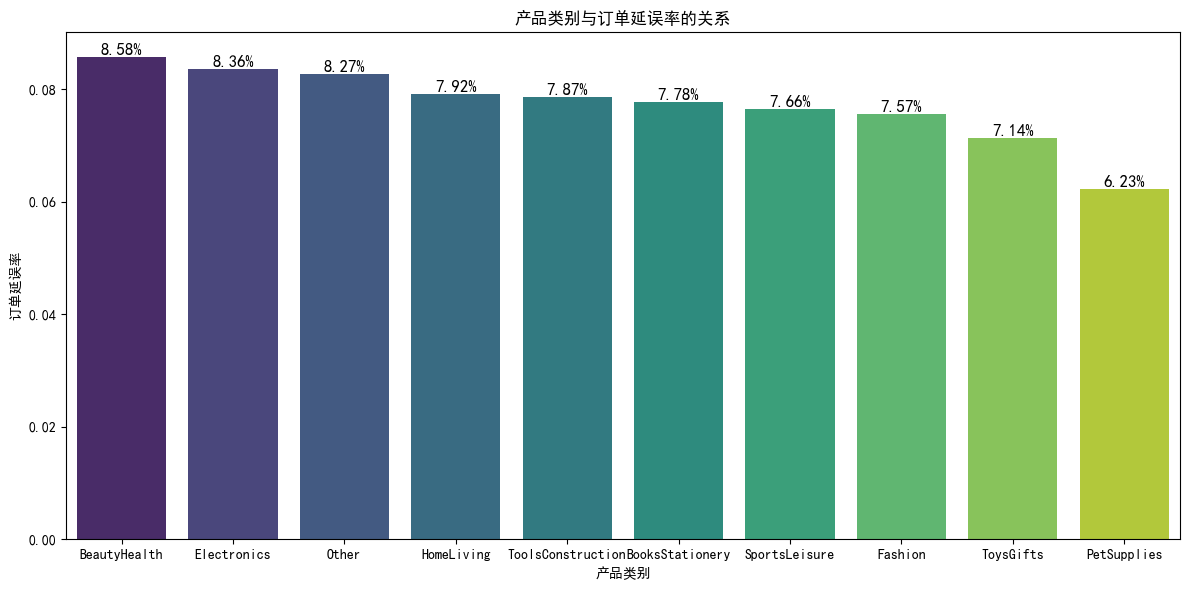

In [35]:
product_category_isdelay_rate = data.groupby('product_category_high')['is_delay'].mean().reset_index()
product_category_isdelay_rate = product_category_isdelay_rate.sort_values(by='is_delay', ascending=False)
plt.figure(figsize=(12,6))
ax9=sns.barplot(x='product_category_high', y='is_delay', data=product_category_isdelay_rate, palette='viridis',hue='product_category_high',legend=False)
for p in ax9.patches:
    height = p.get_height()
    ax9.annotate(
        f'{height:.2%}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', 
        va='bottom',
        fontsize=12
    )
plt.title('产品类别与订单延误率的关系')
plt.xlabel('产品类别')
plt.ylabel('订单延误率')
plt.tight_layout()
plt.show()

美妆健康的商品延误率最高，宠物用品类别的商品延误率最低

## 10.运费与延误率之间的关系

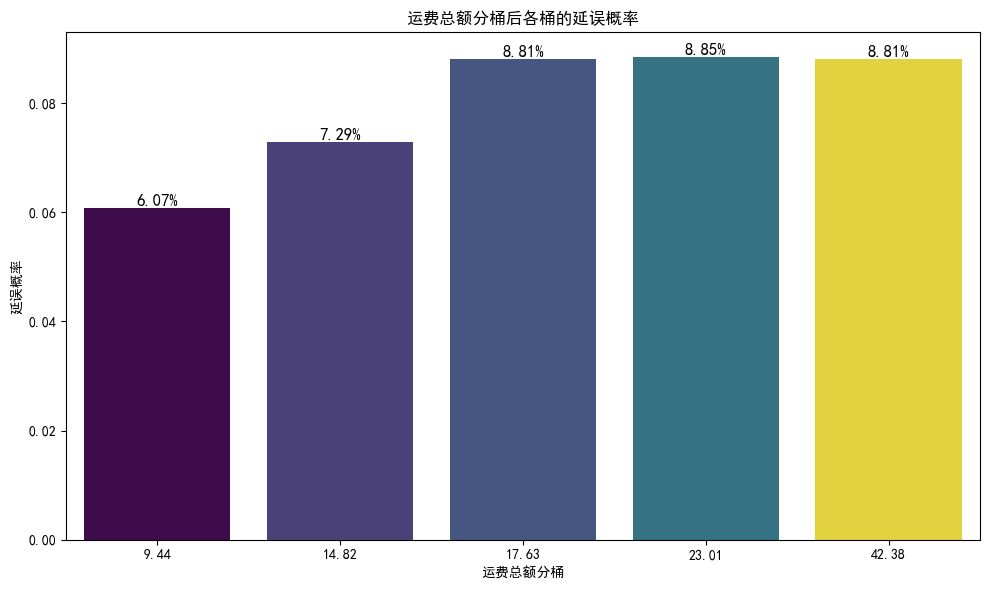

In [39]:
data['freight_total_bin']=pd.qcut(data['freight_total'],q=5)
data['freight_total_bin'] = data.groupby('freight_total_bin', observed=True)['freight_total'].transform('median')
freight_total_isdelay_rate = data.groupby('freight_total_bin')['is_delay'].mean().reset_index()
plt.figure(figsize=(10, 6))
ax10=sns.barplot(x='freight_total_bin', y='is_delay', data=freight_total_isdelay_rate, palette='viridis',hue='freight_total_bin',legend=False)
for p in ax10.patches:
    height = p.get_height()
    ax10.annotate(
        f'{height:.2%}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', 
        va='bottom',
        fontsize=12
    )
plt.title('运费总额分桶后各桶的延误概率')
plt.xlabel('运费总额分桶')
plt.ylabel('延误概率')
plt.tight_layout()
plt.show()

运费与延误率呈现正相关的关系

## 11.订单处理时间与物流延误之间的关系

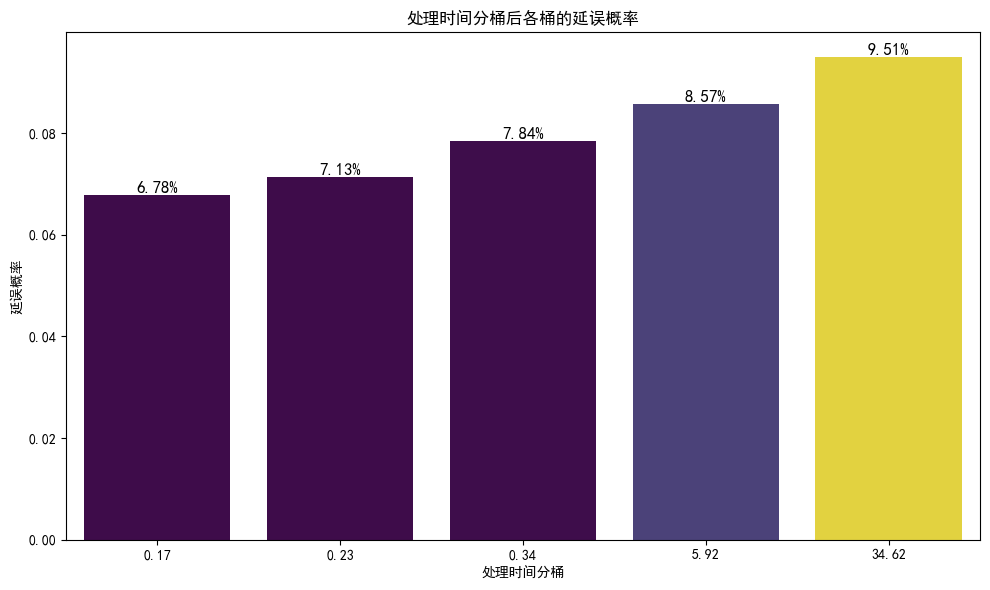

In [46]:
data['process_time_bin']=pd.qcut(data['process_time'],q=5)
data['process_time_bin'] = data.groupby('process_time_bin', observed=True)['process_time'].transform('median').round(2)
process_time_isdelay_rate = data.groupby('process_time_bin')['is_delay'].mean().reset_index()
plt.figure(figsize=(10,6))
ax11=sns.barplot(x='process_time_bin', y='is_delay', data=process_time_isdelay_rate, palette='viridis',hue='process_time_bin',legend=False)
for p in ax11.patches:
    height = p.get_height()
    ax11.annotate(
        f'{height:.2%}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', 
        va='bottom',
        fontsize=12
    )
plt.title('处理时间分桶后各桶的延误概率')
plt.xlabel('处理时间分桶')
plt.ylabel('延误概率')
plt.tight_layout()
plt.show()

订单处理时间与延误率存在正相关的关系，一般订单处理时间长，代表物流紧张
